In [1]:
import os
import locomotif.locomotif as locomotif
from tqdm import tqdm
import pandas as pd

/cw/dtaijupiter/NoCsBack/dtai/daanv/miniconda3/envs/md/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def apply_locomotif_and_store_results(dataset, test=False, **locomotif_params):
    train_or_test = "test" if test else "train"
    filename = f"{train_or_test}_locomotif_" + "_".join([f"{key}={value}" for (key, value) in locomotif_params.items()]) + ".pkl"
    path_to_result = os.path.join(".", "results", dataset.lower(), train_or_test, filename)

    path_to_data = os.path.join("benchmarks", dataset.lower(), f"{train_or_test}.pkl")
    df_ts = pd.read_pickle(path_to_data)

    if os.path.exists(path_to_result):
        # load and return result
        df_results  = pd.read_pickle(path_to_result)
        df_results = df_results.reset_index(drop=True)
        df = pd.concat((df_ts, df_results), axis=1)
        return df
    else:
        # apply
        results = []
        for row in tqdm(df_ts.iterrows()):
            series, _ = row[1]
            motif_sets = locomotif.apply_locomotif(series, **locomotif_params)
            results.append(motif_sets)
            
        df_ts["MotifSets"] = results
        return df_ts

In [3]:
dataset = "CharacterTrajectories"
test    = False

locomotif_params = {'l_min': 83 , 'l_max': 142, 'rho': 0.8, 'warping': True, 'nb': 1}
df_result = apply_locomotif_and_store_results(dataset, test, **locomotif_params)

50it [03:13,  3.88s/it]


+----+----+----+
|    |  1 | MD |
+----+----+----+
| 3  | 10 | 2  |
+----+----+----+
| 17 |  0 | 6  |
+----+----+----+
| FD |  6 | -  |
+----+----+----+
0.625
0.5555555555555556
0.5882352941176471


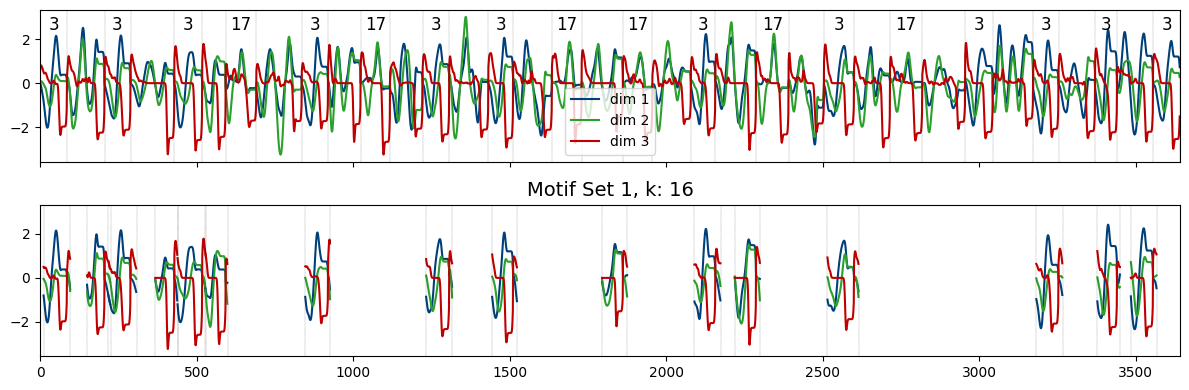

In [8]:
ts, gt, motif_sets, *_ = df_result.iloc[0]

import evaluation
import locomotif.visualize as vis
import matplotlib.pyplot as plt

mm, row_names, col_names = evaluation.match_matrix(gt, motif_sets)
print(evaluation.pretty_print_match_matrix(mm, row_names, col_names))

print(evaluation.precision(mm))
print(evaluation.recall(mm))
print(evaluation.f1_score(mm))

vis.plot_motif_sets(ts, motif_sets, gt)
plt.show()